In [1]:
import json
import os
import random
import flwr as fl
from lightphe import LightPHE
from client import make_client_fn
from strategy import EncryptedFedAvg, weighted_average_metrics
from model import pretrain_SisFall_1DCNN, pretrain_train_model
from data_processing import complete_dataload

## Selecting Clients
The SisFall dataset has two kinds of subjects:
1. Has both ADL data and Fall data (Ussually represented with a 'SA' at the start)
2. Has only ADL data (Ussualy represented with a 'SE' at the start)
For my simulation I will the subjects with both ADL and Fall data for the clients with a binary label of ADL/Fall. For pretraining clients I will select from the subjects with only ADL data and train with the 19 unique ADLs as the label. Subjects will be randomly selected with 15 clients and 8 pretraining subjects. 
> Note: subjects SA01 and SA02 are removed from being selected to prevent data leakage

In [15]:
# Both ADl and Fall
total_client = [ 'SA03', 'SA04', 'SA05', 'SA06', 'SA07', 
                'SA08', 'SA09', 'SA10', 'SA11', 'SA12', 'SA13', 
                'SA14', 'SA15', 'SA16', 'SA17', 'SA18', 
               'SA19', 'SA20', 'SA21', 'SA22', 'SA23', 'SE06']

# Only ADL
total_pretrain = ['SE01', 'SE02', 'SE03', 'SE04', 'SE05', 'SE07', 
               'SE08', 'SE09', 'SE10', 'SE11', 'SE12', 'SE13', 
               'SE14', 'SE15']

num_clients = 15
num_pretrain = 8

client_list = random.sample(total_client, num_clients)
pretrain_list = random.sample(total_pretrain, num_pretrain)

## Calculating Earth Mover's Distance for all Subjects

In [2]:
import numpy as np
import torch

def extract_numpy_from_dataloader(dataloader):
    """
    Extracts all input features from a PyTorch DataLoader and 
    stacks them into a single 3D NumPy array.
    """
    all_windows = []
    
    for inputs, labels in dataloader:
        # Move data to CPU (if on GPU) and convert to NumPy
        batch_numpy = inputs.cpu().detach().numpy()
        all_windows.append(batch_numpy)
        
    # Stack all the batches together into one giant array
    client_data_array = np.vstack(all_windows)
    
    return client_data_array

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance

def calculate_all_emds_and_plot(client_datasets_dict):
    """
    Calculates pairwise EMD for a dictionary of client data and plots a heatmap.
    Expects a dictionary like: {"Client 1": data_array, "Client 2": data_array, ...}
    """
    client_names = list(client_datasets_dict.keys())
    num_clients = len(client_names)
    
    # Create an empty 15x15 matrix filled with zeros
    emd_matrix = np.zeros((num_clients, num_clients))
    
    # 1. Pre-calculate the flattened magnitudes for all clients to save time
    flattened_mags = {}
    for name, data in client_datasets_dict.items():
        # Calculate magnitude: sqrt(X^2 + Y^2 + Z^2) and flatten
        mag = np.sqrt(np.sum(data**2, axis=-1)).flatten()
        flattened_mags[name] = mag

    # 2. Calculate the Pairwise EMD
    print("Calculating Pairwise EMD Matrix...")
    for i in range(num_clients):
        for j in range(i + 1, num_clients): # Only calculate upper triangle
            name_a = client_names[i]
            name_b = client_names[j]
            
            # Calculate EMD between the two clients
            dist = wasserstein_distance(flattened_mags[name_a], flattened_mags[name_b])
            
            # Matrix is symmetric (A to B is same as B to A)
            emd_matrix[i, j] = dist
            emd_matrix[j, i] = dist 
            
    # 3. Generate the Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        emd_matrix, 
        xticklabels=client_names, 
        yticklabels=client_names, 
        annot=False,        # Set to True if you want the exact numbers in the boxes
        cmap="YlOrRd",      # Yellow-Orange-Red color scale
        cbar_kws={'label': "Earth Mover's Distance"}
    )
    
    plt.title("Statistical Heterogeneity (Non-IID) Across All FL Clients")
    plt.tight_layout()
    plt.show()
    
    return emd_matrix

In [4]:
full_dataload = complete_dataload()

Step 1: Loading raw SisFall data into memory...
Step 2: Processing clients...
Step 3: Finalizing Pre-train set (1 clients)...

=== READY ===
Pre-train Set: 120 windows
FL Clients: 37 active clients


Calculating Pairwise EMD Matrix...


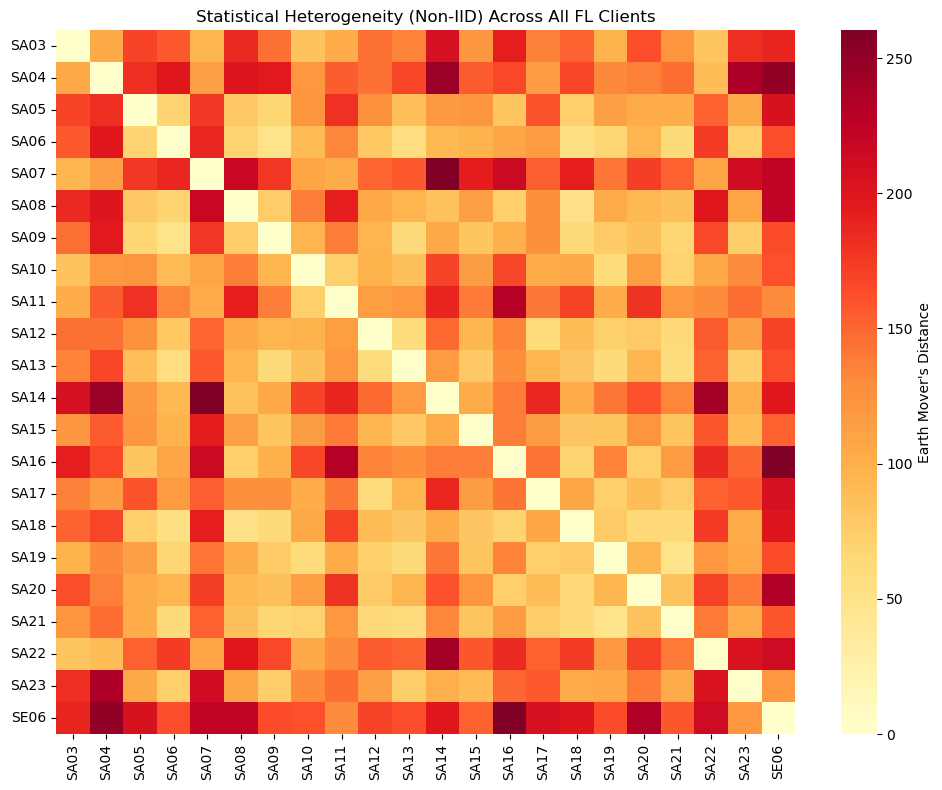

In [25]:
client_dict = full_dataload[1]
filtered_dict = {key: value for key, value in client_dict.items() if key in total_client}

# Extract numpy array from dataloader
numpy_filitered_dict = {key: extract_numpy_from_dataloader(value[0]) for key, value in filtered_dict.items()}
distance_matrix = calculate_all_emds_and_plot(numpy_filitered_dict)

## Generate PHE keys

In [3]:
cs = LightPHE(algorithm_name="Paillier")
cs.export_keys("lightphe_keys.json")

26-03-22 09:54:05 - ⚠️ You did not set public arg to True. So, exported key has private key information.Do not share this to anyone


## Pretraining
For this simulation we are assuming the pretraining data is from a public source which does not have the same privacy concerns as our clients so it is trained without differential privacy. We are also using the subjects which did not have fall data and using the 19 unique ADLs as the labels. 

In [4]:
pretrain_model = pretrain_SisFall_1DCNN()
pretrain_dataloader = pretrain_dataload(pretrain_list)[0]
pretrained_weights = pretrain_train_model(pretrain_model, pretrain_dataloader, num_epochs = 10)

Epoch [1/10] - Training Loss: 46.0275
Epoch [2/10] - Training Loss: 36.2413
Epoch [3/10] - Training Loss: 27.1358
Epoch [4/10] - Training Loss: 19.5424
Epoch [5/10] - Training Loss: 15.6900
Epoch [6/10] - Training Loss: 12.9530
Epoch [7/10] - Training Loss: 10.8094
Epoch [8/10] - Training Loss: 9.0826
Epoch [9/10] - Training Loss: 7.2928
Epoch [10/10] - Training Loss: 5.9719

[PRETRAINING] Pretraining complete. Returning global weights.


In [5]:
# 1. Contruct clients and strategy
encryption = False
diffPrivacy = False
custom_client_fn = make_client_fn(client_list,pretrained_weights, encryption, diffPrivacy)

my_strategy = EncryptedFedAvg(
    use_encryption=encryption,
    fraction_fit=0.2,  
    min_fit_clients=3,
    min_available_clients=len(client_list), # Wait for all clients to be ready
    evaluate_metrics_aggregation_fn=weighted_average_metrics
)


# 2. Run the simulation and capture the history
total_cpus = os.cpu_count()
history = fl.simulation.start_simulation(
    client_fn = custom_client_fn,
    num_clients=len(client_list), 
    config=fl.server.ServerConfig(num_rounds=20),
    strategy=my_strategy,
    client_resources={"num_cpus": total_cpus, "num_gpus": 0.0},
)

# 2. Extract the metrics dictionaries from the History object
results_to_save = {
    "losses_distributed": history.losses_distributed,
    "metrics_distributed": history.metrics_distributed,
}

# 3. Save to a JSON file in your results folder
json_path = "results/"
if encryption and diffPrivacy:
    json_path += "hybrid_metrics.json"
elif encryption and not diffPrivacy:
    json_path += "he_metrics.json"
elif diffPrivacy and not encryption:
    json_path += "dp_metrics.json"
else:
    json_path += "baseline_metrics.json"
    
with open(json_path, "w") as f:
    json.dump(results_to_save, f, indent=4)
    
print("Simulation complete. Results saved to JSON")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
03/22/2026 09:54:24:WARNING:DEPRECATED FEATURE: flwr.simulation.start_simulation() is deprecated.
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=20, no round_timeout
2026-03-22 09:54:29,856	INFO wor

(ClientAppActor pid=27172) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=27172) 
(ClientAppActor pid=27172)             This is a deprecated feature. It will be removed
(ClientAppActor pid=27172)             entirely in future versions of Flower.
(ClientAppActor pid=27172)         
(ClientAppActor pid=27172) 03/22/2026 09:55:15:WARNING:DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=27172) 
(ClientAppActor pid=27172)             This is a deprecated feature. It will be removed
(ClientAppActor pid=27172)             entirely in future versions of Flower.
(ClientA

(ClientAppActor pid=27172) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=27172) 
(ClientAppActor pid=27172)             This is a deprecated feature. It will be removed
(ClientAppActor pid=27172)             entirely in future versions of Flower.
(ClientAppActor pid=27172)         
(ClientAppActor pid=27172) 03/22/2026 09:55:49:WARNING:DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=27172) 
(ClientAppActor pid=27172)             This is a deprecated feature. It will be removed
(ClientAppActor pid=27172)             entirely in future versions of Flower.
(ClientA

(ClientAppActor pid=27172) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=27172) 
(ClientAppActor pid=27172)             This is a deprecated feature. It will be removed
(ClientAppActor pid=27172)             entirely in future versions of Flower.
(ClientAppActor pid=27172)         
(ClientAppActor pid=27172) 03/22/2026 09:56:20:WARNING:DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=27172) 
(ClientAppActor pid=27172)             This is a deprecated feature. It will be removed
(ClientAppActor pid=27172)             entirely in future versions of Flower.
(ClientA

(ClientAppActor pid=27172) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=27172) 
(ClientAppActor pid=27172)             This is a deprecated feature. It will be removed
(ClientAppActor pid=27172)             entirely in future versions of Flower.
(ClientAppActor pid=27172)         
(ClientAppActor pid=27172) 03/22/2026 09:56:39:WARNING:DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=27172) 
(ClientAppActor pid=27172)             This is a deprecated feature. It will be removed
(ClientAppActor pid=27172)             entirely in future versions of Flower.
(ClientA

...

(ClientAppActor pid=27172) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=27172) 
(ClientAppActor pid=27172)             This is a deprecated feature. It will be removed
(ClientAppActor pid=27172)             entirely in future versions of Flower.
(ClientAppActor pid=27172)         
(ClientAppActor pid=27172) 03/22/2026 10:09:19:WARNING:DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=27172) 
(ClientAppActor pid=27172)             This is a deprecated feature. It will be removed
(ClientAppActor pid=27172)             entirely in future versions of Flower.
(ClientA

(ClientAppActor pid=27172) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=27172) 
(ClientAppActor pid=27172)             This is a deprecated feature. It will be removed
(ClientAppActor pid=27172)             entirely in future versions of Flower.
(ClientAppActor pid=27172)         
(ClientAppActor pid=27172) 03/22/2026 10:09:38:WARNING:DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=27172) 
(ClientAppActor pid=27172)             This is a deprecated feature. It will be removed
(ClientAppActor pid=27172)             entirely in future versions of Flower.
(ClientA

INFO :      aggregate_evaluate: received 15 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 20 round(s) in 907.96s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.1689179264271149
INFO :      		round 2: 0.29261176033704367
INFO :      		round 3: 0.1363599069778704
INFO :      		round 4: 0.1160711564047745
INFO :      		round 5: 0.20261685451492667
INFO :      		round 6: 0.10859001550271555
INFO :      		round 7: 0.09655717027632313
INFO :      		round 8: 0.09754927092844068
INFO :      		round 9: 0.08759026503431852
INFO :      		round 10: 0.1087096201156749
INFO :      		round 11: 0.09689534700329036
INFO :      		round 12: 0.22821529227972928
INFO :      		round 13: 0.08527886064231603
INFO :      		round 14: 0.0987363947250695
INFO :      		round 15: 0.10222561810683045
INFO :      		round 16: 0.04759216488045813
INFO :      		round 17: 0.06382538118977445
INFO :      		round 18: 0.060609251432319135
INFO :      		round 19: 0.090

INFO :      	               (10, 0.977725243765683),
INFO :      	               (11, 0.9536863884484009),
INFO :      	               (12, 0.9207942199619945),
INFO :      	               (13, 0.9570103174499832),
INFO :      	               (14, 0.9653834551967779),
INFO :      	               (15, 0.9746588268042925),
INFO :      	               (16, 0.9711408820417421),
INFO :      	               (17, 0.9757914705730933),
INFO :      	               (18, 0.9842273817739656),
INFO :      	               (19, 0.961946943057517),
INFO :      	               (20, 0.980408197315174)],
INFO :      	 'recall': [(1, 0.9078026683112679),
INFO :      	            (2, 0.9583116401191242),
INFO :      	            (3, 0.9424309230546905),
INFO :      	            (4, 0.9571861008474013),
INFO :      	            (5, 0.9586783029679107),
INFO :      	            (6, 0.9310262001914223),
INFO :      	            (7, 0.9186425400440404),
INFO :      	            (8, 0.9533793552135813),
INFO :  

Simulation complete. Results saved to JSON
